In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("phase 2 data.csv")
df

,Index,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,0,0.0,1.0,1.0,1.0,1.316755,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
1,1,0.0,0.0,0.0,0.0,-0.312639,1.0,0.0,0.0,1.0,...,0,1,1,0,0,0,0,0,0,0
2,2,0.0,1.0,1.0,1.0,0.140916,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,3,0.0,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,4,0.0,1.0,1.0,1.0,-0.486739,0.0,0.0,0.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,253675,0.0,1.0,1.0,1.0,1.633059,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,1,0
253676,253676,2.0,1.0,1.0,1.0,-1.893247,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,253677,0.0,0.0,0.0,1.0,0.140916,0.0,0.0,0.0,1.0,...,1,0,0,1,0,0,0,0,0,0
253678,253678,0.0,1.0,0.0,1.0,-0.674597,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,0,0,0,0


Artifical Neural Networks

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold

X = df.drop(columns=["Diabetes_012","Index"])
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,1.0,1.0,1.0,1.316755,1.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,1,0,0,0,0,0
1,0.0,0.0,0.0,-0.312639,1.0,0.0,0.0,1.0,0.0,0.0,...,0,1,1,0,0,0,0,0,0,0
2,1.0,1.0,1.0,0.140916,0.0,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,1.0,1.0,1.0,-0.486739,0.0,0.0,0.0,1.0,1.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1.0,1.0,1.0,1.633059,0.0,0.0,0.0,0.0,1.0,1.0,...,0,1,0,0,0,0,0,0,1,0
253676,1.0,1.0,1.0,-1.893247,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,0.0,0.0,1.0,0.140916,0.0,0.0,0.0,1.0,1.0,0.0,...,1,0,0,1,0,0,0,0,0,0
253678,1.0,0.0,1.0,-0.674597,0.0,0.0,0.0,0.0,1.0,1.0,...,1,0,1,0,0,0,0,0,0,0


In [6]:
y= df["Diabetes_012"]
y

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
253675    0.0
253676    2.0
253677    0.0
253678    0.0
253679    2.0
Name: Diabetes_012, Length: 253680, dtype: float64

In [7]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
kf

KFold(n_splits=10, random_state=42, shuffle=True)

4 Hidden layers of size 10

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
mlp = MLPClassifier(hidden_layer_sizes=(10,10,10,10), max_iter=1000, random_state=0, activation="relu", solver="adam")


In [34]:
Precision = []
Recall = []
F1 = []
Accuracy = []
AUC = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    y_pred_proba = mlp.predict_proba(X_test)
    Precision.append(precision_score(y_test, y_pred, average=None))
    Recall.append(recall_score(y_test, y_pred, average=None))
    F1.append(f1_score(y_test, y_pred, average=None))
    Accuracy.append(accuracy_score(y_test, y_pred))
    AUC.append(roc_auc_score(y_test, y_pred_proba, multi_class='ovr'))
Precision, Recall, F1, Accuracy, AUC

C:\Users\Dell-\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell-\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell-\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

([array([0.86127593, 0.        , 0.5810956 ]),
  array([0.86320813, 0.        , 0.5739868 ]),
  array([0.86157577, 0.        , 0.55159113]),
  array([0.85860806, 0.        , 0.60275689]),
  array([0.86407205, 0.        , 0.58075601]),
  array([0.86040964, 0.        , 0.60151803]),
  array([0.86179632, 0.        , 0.55760369]),
  array([0.86122533, 0.        , 0.58110687]),
  array([0.86404508, 0.        , 0.52631579]),
  array([0.86417706, 0.        , 0.55761483])],
 [array([0.98345872, 0.        , 0.15483686]),
  array([0.98074226, 0.        , 0.17385098]),
  array([0.98026654, 0.        , 0.16333524]),
  array([0.98630137, 0.        , 0.1359141 ]),
  array([0.97898235, 0.        , 0.18983432]),
  array([0.98188304, 0.        , 0.17625799]),
  array([0.97963674, 0.        , 0.17148526]),
  array([0.98084668, 0.        , 0.17073171]),
  array([0.9744836 , 0.        , 0.18492176]),
  array([0.97653506, 0.        , 0.19548023])],
 [array([0.91832104, 0.        , 0.24451977]),
  array([0.

In [35]:
Precision = np.array(Precision)
Recall = np.array(Recall)
F1 = np.array(F1)
Accuracy = np.array(Accuracy)
AUC = np.array(AUC)

In [36]:
Diabetes_0_Precision = Precision[:, 0].mean()
Diabetes_1_Precision = Precision[:, 1].mean()
Diabetes_2_Precision = Precision[:, 2].mean()
Diabetes_0_Recall = Recall[:, 0].mean()
Diabetes_1_Recall = Recall[:, 1].mean()
Diabetes_2_Recall = Recall[:, 2].mean()
Diabetes_0_F1 = F1[:, 0].mean()
Diabetes_1_F1 = F1[:, 1].mean()
Diabetes_2_F1 = F1[:, 2].mean()
Diabetes_Accuracy = Accuracy.mean()
Diabetes_AUC = AUC.mean()
Diabetes_0_Precision, Diabetes_1_Precision, Diabetes_2_Precision, Diabetes_0_Recall, Diabetes_1_Recall, Diabetes_2_Recall, Diabetes_0_F1, Diabetes_1_F1, Diabetes_2_F1, Diabetes_Accuracy, Diabetes_AUC

(0.8620393378166018,
 0.0,
 0.5714345634921809,
 0.9803136354624005,
 0.0,
 0.17166484520207884,
 0.9173741740749671,
 0.0,
 0.2633395836239366,
 0.8497516556291391,
 0.7870915914217299)

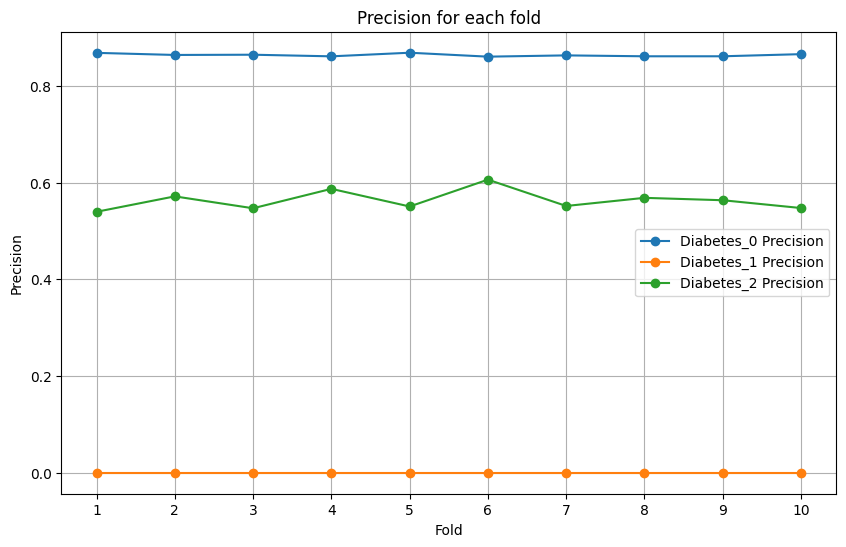

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), Precision[:, 0], marker='o', label='Diabetes_0 Precision')
plt.plot(range(1, 11), Precision[:, 1], marker='o', label='Diabetes_1 Precision')
plt.plot(range(1, 11), Precision[:, 2], marker='o', label='Diabetes_2 Precision')
plt.title('Precision for each fold')
plt.xlabel('Fold')
plt.ylabel('Precision')
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show() 

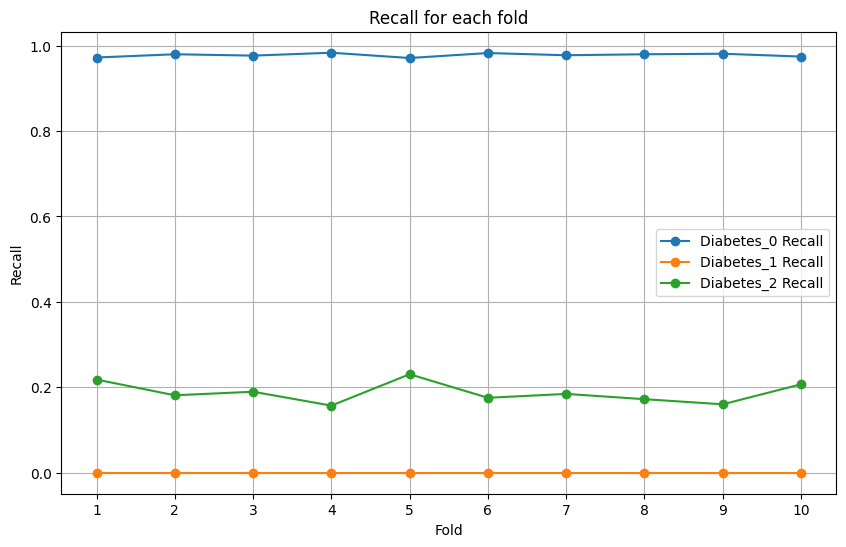

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,11), Recall[:, 0], marker='o', label='Diabetes_0 Recall')
plt.plot(range(1,11), Recall[:, 1], marker='o', label="Diabetes_1 Recall")
plt.plot(range(1,11), Recall[:, 2], marker='o', label="Diabetes_2 Recall")
plt.title("Recall for each fold")
plt.xlabel("Fold")
plt.ylabel("Recall")
plt.xticks(range(1,11))
plt.legend()
plt.grid()
plt.show()

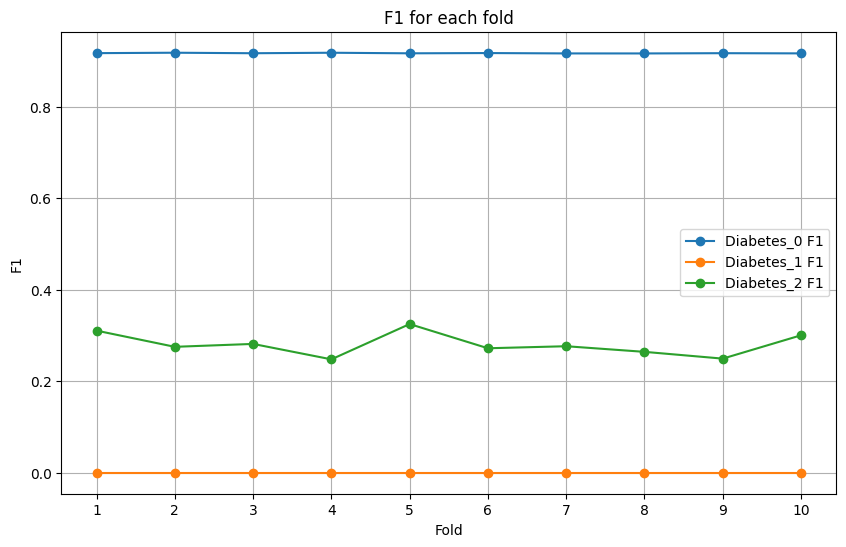

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,11), F1[:, 0], marker='o', label='Diabetes_0 F1')
plt.plot(range(1,11), F1[:, 1], marker='o', label='Diabetes_1 F1')
plt.plot(range(1,11), F1[:, 2], marker='o', label='Diabetes_2 F1')
plt.title("F1 for each fold")
plt.xlabel("Fold")
plt.ylabel("F1")
plt.xticks(range(1,11))
plt.legend()
plt.grid()
plt.show()

In [ ]:
Diabetes_Dict = {
    "Diabetes_0_Precision": Diabetes_0_Precision,
    "Diabetes_1_Precision": Diabetes_1_Precision,
    "Diabetes_2_Precision": Diabetes_2_Precision,
    "Diabetes_0_Recall": Diabetes_0_Recall,
    "Diabetes_1_Recall": Diabetes_1_Recall,
    "Diabetes_2_Recall": Diabetes_2_Recall,
    "Diabetes_0_F1": Diabetes_0_F1,
    "Diabetes_1_F1": Diabetes_1_F1,
    "Diabetes_2_F1": Diabetes_2_F1,
    "Diabetes_Accuracy": Diabetes_Accuracy,
    "Diabetes_AUC": Diabetes_AUC
}

Diabetes_Frame = pd.DataFrame(Diabetes_Dict, index=[0])
Diabetes_Frame.to_csv("Diabetes_Results_Decision_Tree.csv", index=False)
Diabetes_Frame

,Diabetes_0_Precision,Diabetes_1_Precision,Diabetes_2_Precision,Diabetes_0_Recall,Diabetes_1_Recall,Diabetes_2_Recall,Diabetes_0_F1,Diabetes_1_F1,Diabetes_2_F1,Diabetes_Accuracy,Diabetes_AUC
0,0.862039,0.0,0.571435,0.980314,0.0,0.171665,0.917374,0.0,0.26334,0.849752,0.787092


: 